In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json,os
import seaborn as sns


In [89]:
PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "experiment2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [90]:
import os

json_path = "/outputs/results/capacity_to_csv_20260320_221239_923608.json"

full_json_path =   PROJECT_ROOT / 'outputs' / 'results' / 'capacity_to_csv_20260320_221239_923608.json'
print(full_json_path)

/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/results/capacity_to_csv_20260320_221239_923608.json


In [91]:
with open(full_json_path, "r", encoding="utf-8") as f:
    cap2csv = json.load(f)
cap2csv

{'50': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap50_20260320_204809_401992_8204.csv',
 '60': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap60_20260320_204827_732125_8206.csv',
 '70': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap70_20260320_204845_663193_8203.csv',
 '80': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap80_20260320_204910_520629_8205.csv',
 '90': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap90_20260320_210548_583886_8204.csv',
 '100': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap100_20260320_210614_373095_8206.csv',
 '110': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap110_20260320_210646_850440

In [92]:
import pandas as pd

# cap2csv 是你 json load 出来的 dict，key 是 '50','60',... value 是 csv 路径

dfs = {}
for cap_str, csv_path in cap2csv.items():
    cap = int(cap_str)
    df = pd.read_csv(csv_path)
    var_name = f"df{cap}"
    globals()[var_name] = df
    dfs[cap] = df

# 现在你可以直接用 df50, df60, ...
df50.head()

,episode,hotel_revenue,ota_profit,bookings_online,bookings_offline,total_subsidy,avg_subsidy_amount,avg_subsidy_ratio
0,1,1.910816e+06,84847.036270,6552,10901,65978.435202,10.069969,0.411310
1,2,1.857683e+06,88810.710423,7064,10381,68361.914462,9.677508,0.320264
2,3,1.900834e+06,81528.216316,6566,11395,64359.305405,9.801905,0.592120
3,4,1.900251e+06,81718.846309,6565,11492,61440.998003,9.358873,0.135103
4,5,1.904317e+06,78903.733197,6254,11868,59011.680216,9.435830,0.320292


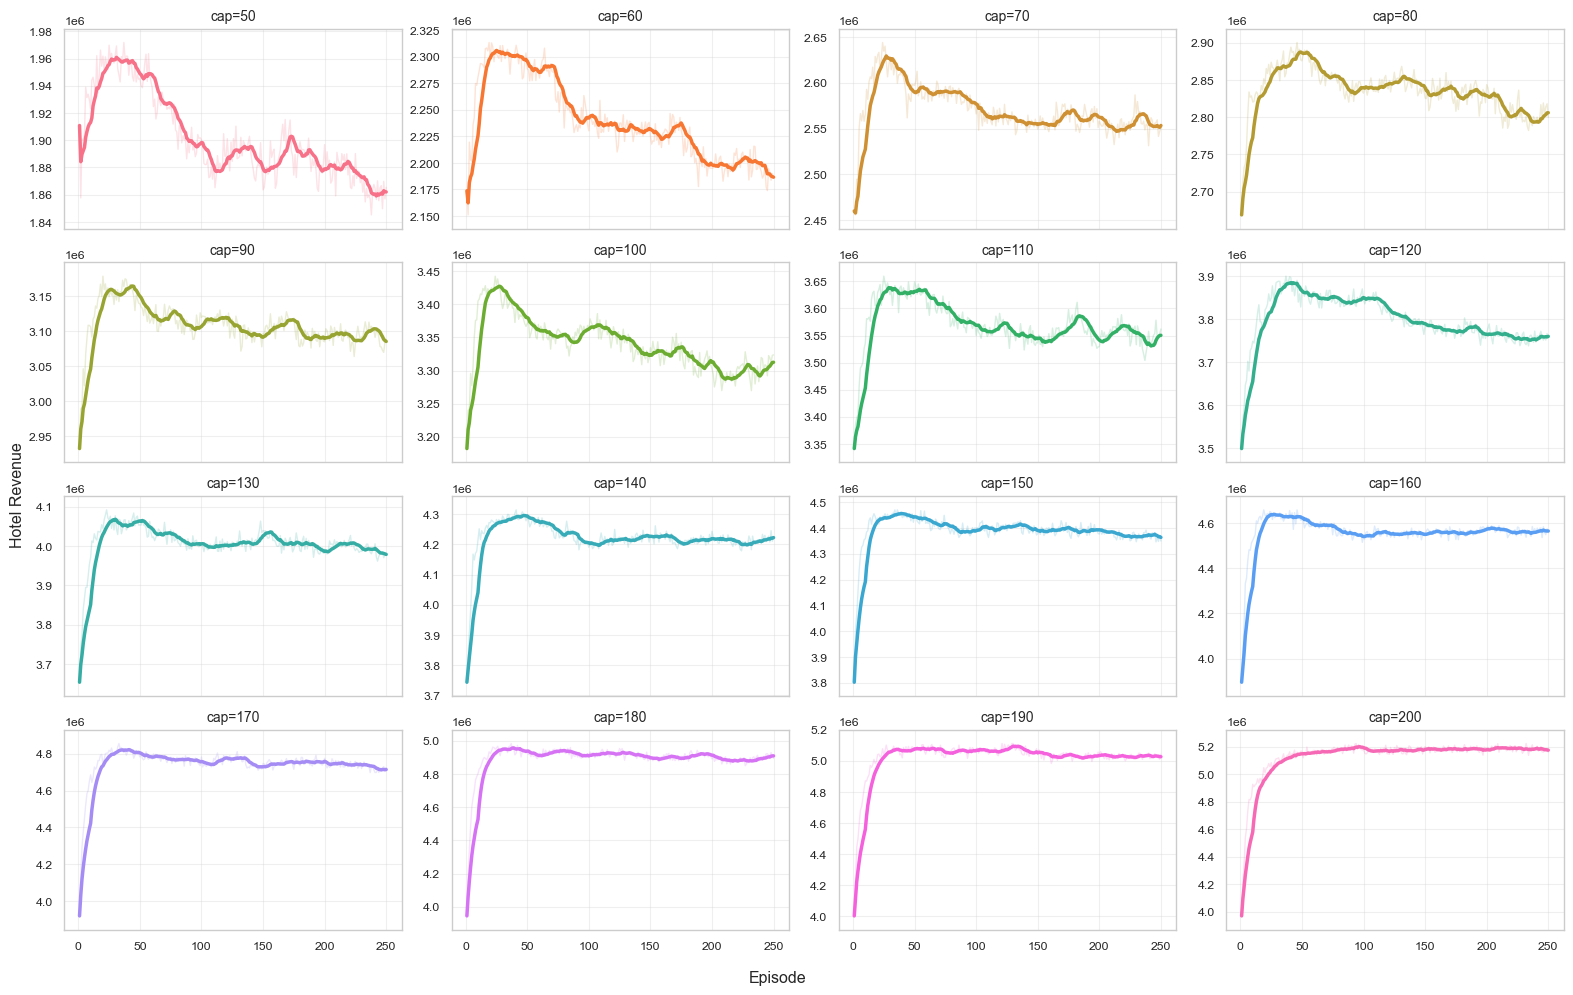

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===== 可调参数 =====
METRIC = "hotel_revenue"   # 可改: "ota_profit" / "bookings_online" / "bookings_offline" / "avg_subsidy_ratio"
Y_LABEL = "Hotel Revenue"
TITLE = "Hotel Revenue by Capacity (4x4)"
ROLLING_WINDOW = 10
FIG_SIZE = (16, 10)

# 风格尽量贴近 experiment1 A1_triptych（简洁、raw+MA）
sns.set_theme(style="whitegrid", context="paper")

caps = sorted(dfs.keys())  # 你现有结构：dfs[cap] = df
nrows, ncols = 4, 4

fig, axes = plt.subplots(nrows, ncols, figsize=FIG_SIZE, sharex=True, sharey=False)
axes = axes.flatten()

palette = sns.color_palette("husl", n_colors=len(caps))

for i, cap in enumerate(caps):
    ax = axes[i]
    d = dfs[cap].copy().sort_values("episode")

    x = d["episode"]
    y_raw = d[METRIC]
    y_ma = y_raw.rolling(ROLLING_WINDOW, min_periods=1).mean()

    color = palette[i]

    # raw 曲线（浅）
    ax.plot(x, y_raw, alpha=0.20, linewidth=1.0, color=color, label="raw")
    # MA 曲线（粗）
    ax.plot(x, y_ma, linewidth=2.5, color=color, label=f"MA{ROLLING_WINDOW}")

    # ===== y轴动态范围（按该cap自身数据）=====
    y_min = np.nanmin(np.r_[y_raw.values, y_ma.values])
    y_max = np.nanmax(np.r_[y_raw.values, y_ma.values])

    if np.isfinite(y_min) and np.isfinite(y_max):
        if y_max > y_min:
            pad = 0.08 * (y_max - y_min)   # 上下各留8%
            ax.set_ylim(y_min - pad, y_max + pad)
        else:
            # 防止常数序列导致上下限相同
            base = abs(y_max) if y_max != 0 else 1.0
            ax.set_ylim(y_min - 0.1 * base, y_max + 0.1 * base)

    ax.set_title(f"cap={cap}", fontsize=10)
    ax.grid(True, alpha=0.3)

# 关闭多余子图（如果不是16个）
for j in range(len(caps), nrows * ncols):
    axes[j].axis("off")

#fig.suptitle(TITLE, y=1.02, fontsize=14)
fig.supxlabel("Episode")
fig.supylabel(Y_LABEL)

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / f"{METRIC}_by_capacity.pdf", dpi=300, bbox_inches="tight")    


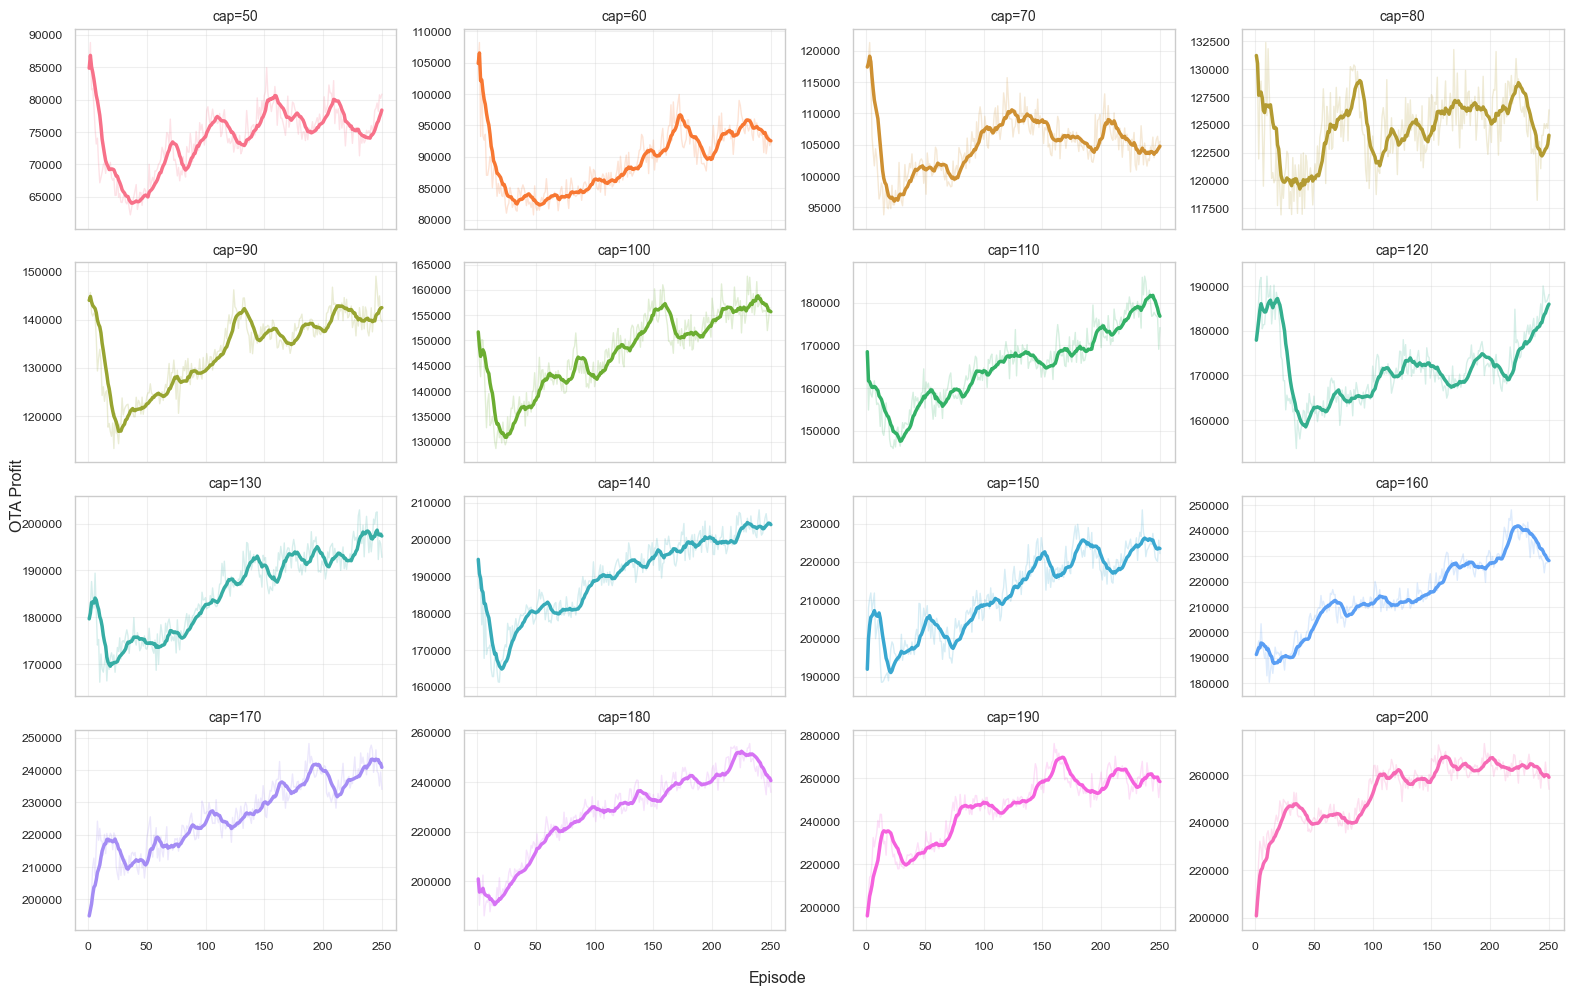

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===== 可调参数 =====
METRIC = "ota_profit"   # 可改: "ota_profit" / "bookings_online" / "bookings_offline" / "avg_subsidy_ratio"
Y_LABEL = "OTA Profit"
TITLE = "OTA Profit by Capacity (4x4)"
ROLLING_WINDOW = 10
FIG_SIZE = (16, 10)

# 风格尽量贴近 experiment1 A1_triptych（简洁、raw+MA）
sns.set_theme(style="whitegrid", context="paper")

caps = sorted(dfs.keys())  # 你现有结构：dfs[cap] = df
nrows, ncols = 4, 4

fig, axes = plt.subplots(nrows, ncols, figsize=FIG_SIZE, sharex=True, sharey=False)
axes = axes.flatten()

palette = sns.color_palette("husl", n_colors=len(caps))

for i, cap in enumerate(caps):
    ax = axes[i]
    d = dfs[cap].copy().sort_values("episode")

    x = d["episode"]
    y_raw = d[METRIC]
    y_ma = y_raw.rolling(ROLLING_WINDOW, min_periods=1).mean()

    color = palette[i]

    # raw 曲线（浅）
    ax.plot(x, y_raw, alpha=0.20, linewidth=1.0, color=color, label="raw")
    # MA 曲线（粗）
    ax.plot(x, y_ma, linewidth=2.5, color=color, label=f"MA{ROLLING_WINDOW}")

    # ===== y轴动态范围（按该cap自身数据）=====
    y_min = np.nanmin(np.r_[y_raw.values, y_ma.values])
    y_max = np.nanmax(np.r_[y_raw.values, y_ma.values])

    if np.isfinite(y_min) and np.isfinite(y_max):
        if y_max > y_min:
            pad = 0.08 * (y_max - y_min)   # 上下各留8%
            ax.set_ylim(y_min - pad, y_max + pad)
        else:
            # 防止常数序列导致上下限相同
            base = abs(y_max) if y_max != 0 else 1.0
            ax.set_ylim(y_min - 0.1 * base, y_max + 0.1 * base)

    ax.set_title(f"cap={cap}", fontsize=10)
    ax.grid(True, alpha=0.3)

# 关闭多余子图（如果不是16个）
for j in range(len(caps), nrows * ncols):
    axes[j].axis("off")

#fig.suptitle(TITLE, y=1.02, fontsize=14)
fig.supxlabel("Episode")
fig.supylabel(Y_LABEL)

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / f"{METRIC}_by_capacity.pdf", dpi=300, bbox_inches="tight")    


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ====== 前提：你已有 dfs 字典（key=cap, value=df{cap}）======
# df 必须包含: episode, bookings_online, bookings_offline

# 1) 汇总每个容量最后一个episode
rows = []
for cap, df in dfs.items():
    d = df.sort_values("episode").copy()
    last = d.iloc[-1]  # 最后一个episode
    online = float(last["bookings_online"])   # OTA
    offline = float(last["bookings_offline"]) # Hotel Direct
    total = online + offline
    ota_share = online / total if total > 0 else np.nan
    direct_share = offline / total if total > 0 else np.nan

    rows.append({
        "capacity": int(cap),
        "bookings_online": online,
        "bookings_offline": offline,
        "bookings_total": total,
        "ota_share": ota_share,
        "direct_share": direct_share,
        "last_episode": int(last["episode"])
    })

summary = pd.DataFrame(rows).sort_values("capacity").reset_index(drop=True)
summary

,capacity,bookings_online,bookings_offline,bookings_total,ota_share,direct_share,last_episode
0,50,5725.0,14269.0,19994.0,0.286336,0.713664,250
1,60,6072.0,17337.0,23409.0,0.259387,0.740613,250
2,70,6723.0,19745.0,26468.0,0.254005,0.745995,250
3,80,7898.0,21989.0,29887.0,0.264262,0.735738,250
4,90,9089.0,23882.0,32971.0,0.275666,0.724334,250
5,100,10036.0,26167.0,36203.0,0.277215,0.722785,250
6,110,11356.0,27664.0,39020.0,0.291030,0.708970,250
7,120,12305.0,29251.0,41556.0,0.296106,0.703894,250
8,130,12884.0,31309.0,44193.0,0.291539,0.708461,250
9,140,13482.0,32977.0,46459.0,0.290191,0.709809,250


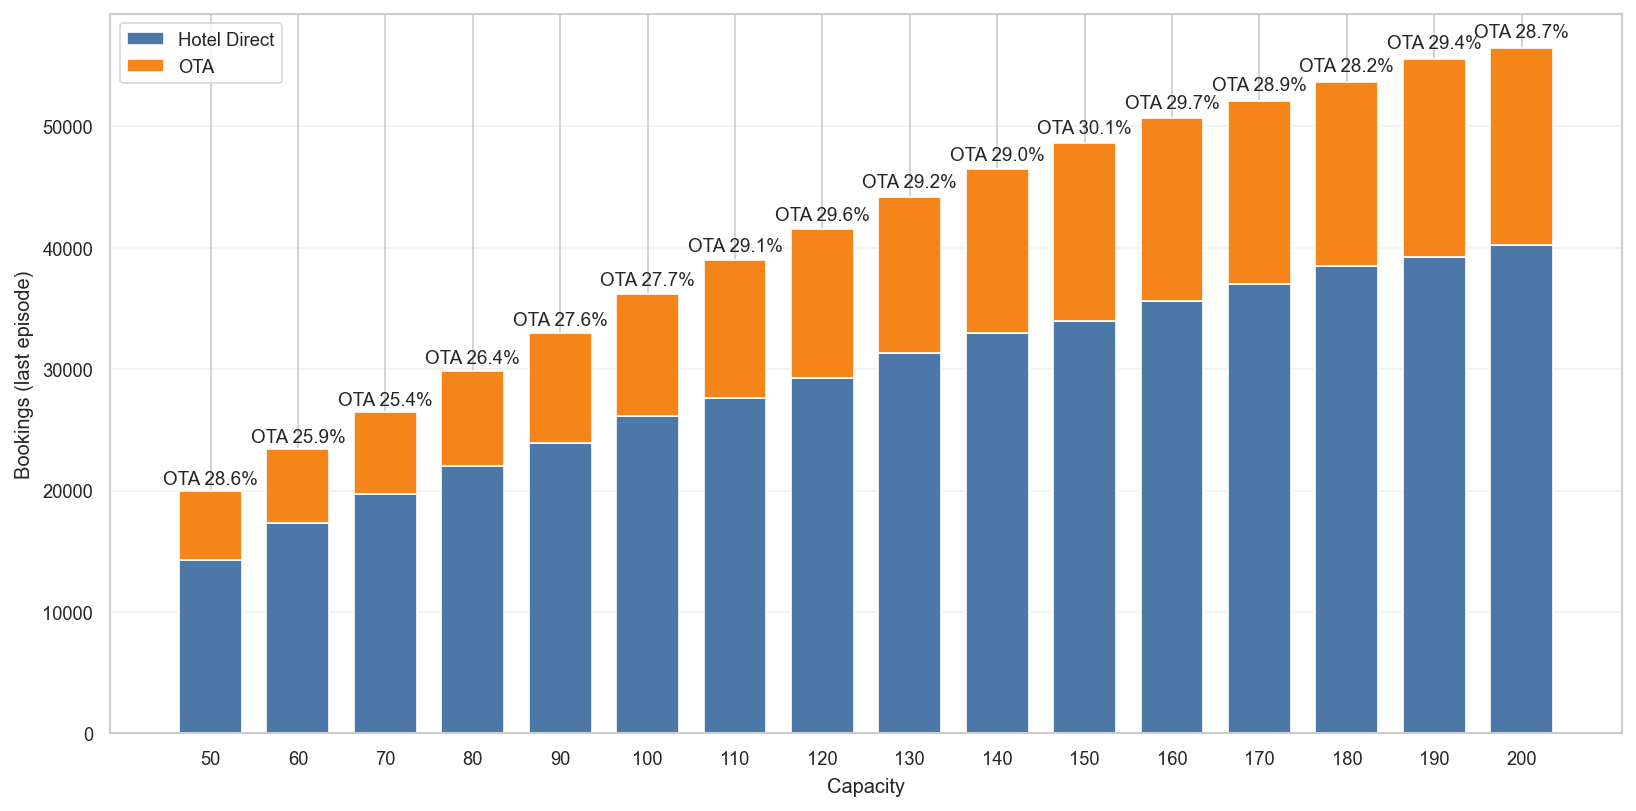

In [96]:
# 2) 画堆叠柱状图（市场份额）
sns.set_theme(style="whitegrid", context="paper")

x = np.arange(len(summary))
caps = summary["capacity"].astype(int).tolist()

offline_vals = summary["bookings_offline"].values  # Hotel Direct
online_vals = summary["bookings_online"].values    # OTA
totals = summary["bookings_total"].values
ota_share = summary["ota_share"].values

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=150)

# 风格尽量简洁、论文友好
color_direct = "#4C78A8"  # 蓝
color_ota = "#F58518"     # 橙

bars_direct = ax.bar(
    x, offline_vals, width=0.72, color=color_direct, label="Hotel Direct"
)
bars_ota = ax.bar(
    x, online_vals, width=0.72, bottom=offline_vals, color=color_ota, label="OTA"
)

# 标注 OTA 份额（柱顶）
for i in range(len(summary)):
    if totals[i] > 0:
        ax.text(
            x[i], totals[i] * 1.01,
            f"OTA {ota_share[i]*100:.1f}%",
            ha="center", va="bottom", fontsize=9
        )

# 可选：标注总订单量
#for i in range(len(summary)):
#    ax.text(
#        x[i], totals[i] * 1.06,
#        f"{int(totals[i])}",
#        ha="center", va="bottom", fontsize=8, color="gray"
#    )

ax.set_xticks(x, caps)
ax.set_xlabel("Capacity")
ax.set_ylabel("Bookings (last episode)")
#ax.set_title("Market Share by Capacity (Last Episode, Stacked Bookings)")
ax.legend(loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / "market_share_by_capacity.pdf", dpi=300, bbox_inches="tight")


In [97]:
full_json_path_model =   PROJECT_ROOT / 'outputs' / 'results' / 'capacity_to_model_20260320_221239_923608.json'
print(full_json_path_model)


/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/results/capacity_to_model_20260320_221239_923608.json


In [98]:
import json
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

cap2model["200"]  # -> {'hotel_online': '...', 'hotel_offline': '...', 'ota': '...'}

{'hotel_online': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_online_cap200_20260320_221238_496409_8205_agent_20260320_221238.json',
 'hotel_offline': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_offline_cap200_20260320_221238_496409_8205_agent_20260320_221238.json',
 'ota': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/ota_cap200_20260320_221238_496409_8205_agent_20260320_221238.json'}

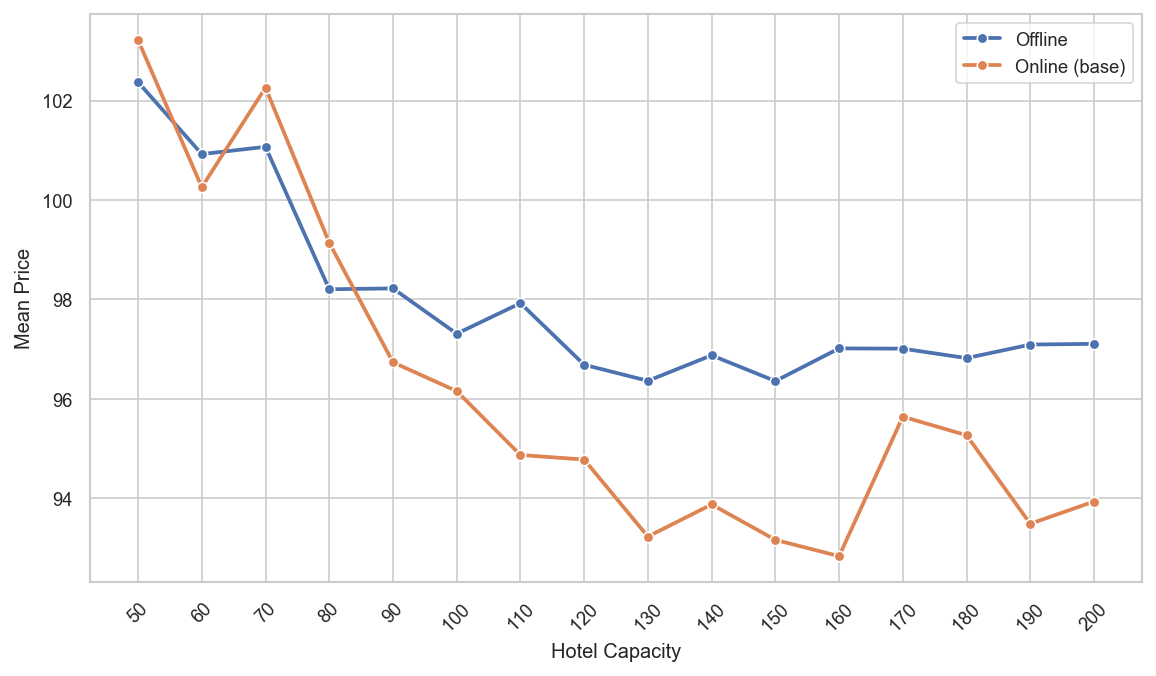

In [99]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 读 capacity->model 路径映射
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

def weighted_mean_from_cem_json(model_path: str, default_val: float = 130.0, tol: float = 1e-9) -> float:
    with open(model_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means = d.get("cem_online_means") or d.get("cem_means")
    visits = d.get("cem_online_state_visit_count") or d.get("cem_state_visit_count")

    if not means or not visits:
        raise ValueError(f"Missing means or visit_count in {model_path}")

    num = 0.0
    den = 0.0

    for k, v in means.items():
        v = float(v)
        if abs(v - default_val) <= tol:
            continue  # 剔除默认值

        w = int(visits.get(k, 0))
        if w <= 0:
            continue

        num += v * w
        den += w

    return float(num / den) if den > 0 else float("nan")
rows = []
for cap_str, paths in cap2model.items():
    cap = int(cap_str)
    online_path = paths.get("hotel_online")
    offline_path = paths.get("hotel_offline")
    if not online_path or not offline_path:
        continue

    online_mean = weighted_mean_from_cem_json(online_path)
    offline_mean = weighted_mean_from_cem_json(offline_path)

    rows.append({"capacity": cap, "price_type": "Online (base)", "mean_price": online_mean})
    rows.append({"capacity": cap, "price_type": "Offline", "mean_price": offline_mean})

plot_df = pd.DataFrame(rows).sort_values(["capacity", "price_type"])

# 2) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(7.8, 4.6), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x="capacity",
    y="mean_price",
    hue="price_type",
    marker="o",
    linewidth=1.8,
    markersize=5,
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xlabel("Hotel Capacity")
ax.set_ylabel("Mean Price")
#ax.set_title("Mean Learned Prices vs Capacity (CEM Policy Means)")

# x轴显示所有capacity（如果太密可以注释掉这行或旋转）
ax.set_xticks(sorted(plot_df["capacity"].unique()))
ax.tick_params(axis="x", rotation=45)

# legend 放图外，避免挡线
# 1. 将图例移至图内 (例如右上角)
# loc='upper right' 会自动寻找最佳位置，也可以手动微调
ax.legend(title="", loc="upper right", frameon=True)

# 2. 添加外边框
# sns.despine(top=False, right=False) 会保留四个方向的边框线
sns.despine(top=False, right=False, left=False, bottom=False)



plt.tight_layout()
plt.show()

ax.figure.savefig(FIG_DIR / "mean_prices_vs_capacity.pdf", dpi=300, bbox_inches="tight")

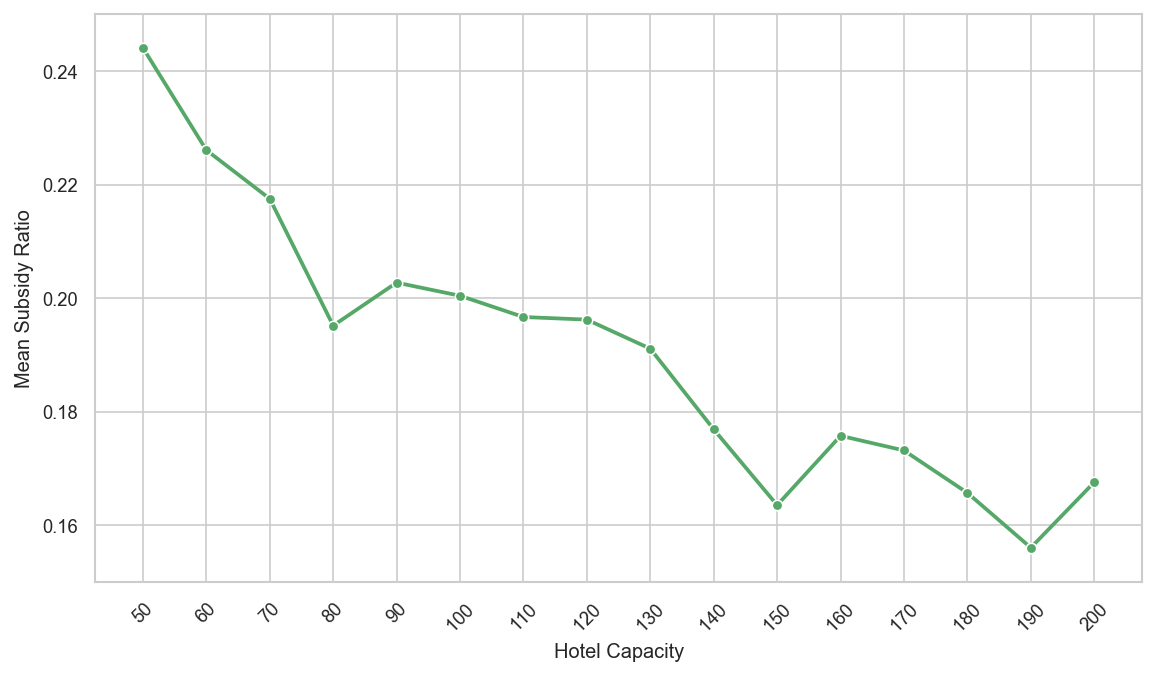

In [100]:
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

def weighted_mean_subsidy_from_ota_json(model_path: str, default_val: float = 0.4, tol: float = 1e-9) -> float:
    with open(model_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means = d.get("cem_means") or d.get("cem_online_means")
    visits = d.get("cem_state_visit_count") or d.get("cem_online_state_visit_count")

    if not means or not visits:
        raise ValueError(f"Missing means or visit_count in {model_path}")

    num = 0.0
    den = 0.0
    for k, v in means.items():
        v = float(v)
        if abs(v - default_val) <= tol:
            continue  # 剔除默认0.4

        w = int(visits.get(k, 0))
        if w <= 0:
            continue

        num += v * w
        den += w

    return float(num / den) if den > 0 else float("nan")

rows = []
for cap_str, paths in cap2model.items():
    cap = int(cap_str)
    ota_path = paths.get("ota")
    if not ota_path:
        continue
    mean_sr = weighted_mean_subsidy_from_ota_json(ota_path)
    rows.append({"capacity": cap, "mean_subsidy_ratio": mean_sr})

plot_df = pd.DataFrame(rows).sort_values("capacity")

sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(7.8, 4.6), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x="capacity",
    y="mean_subsidy_ratio",
    marker="o",
    linewidth=1.8,
    markersize=5,
    color="#55A868"
)

ax.set_xlabel("Hotel Capacity")
ax.set_ylabel("Mean Subsidy Ratio")
#ax.set_title("Mean Learned Subsidy Ratio vs Capacity (CEM Policy Means)")

ax.set_ylim(0.15, 0.25)


ax.set_xticks(sorted(plot_df["capacity"].unique()))
ax.tick_params(axis="x", rotation=45)

sns.despine(top=False, right=False, left=False, bottom=False)

plt.tight_layout()
plt.show()

ax.figure.savefig(FIG_DIR / "mean_subsidy_ratio_vs_capacity.pdf", dpi=300, bbox_inches="tight")


In [101]:
import os
import sys
import ast
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 基础配置 =====
PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.environment.hotel_env import HotelEnvironment

DAYS = 365
BOOKING_WINDOW_DAYS = 91
DECISION_BUCKETS = "0|1|2-3|4-6|7-13|14-29|30-59|60-90"
COMMISSION_RATE = 0.20
MIN_VISITS_PER_STATE = 5

CAPS = list(range(50, 201, 10))

# ===== 读历史数据 =====
historical_data = pd.read_csv(PROJECT_ROOT / "datasets" / "hotel_bookings.csv")
historical_data = historical_data[historical_data["hotel"] == "City Hotel"].copy()

MODELS_DIR = PROJECT_ROOT / "outputs" / "models"


def parse_buckets(spec: str, n: int):
    tokens = [t.strip() for t in str(spec).replace(",", "|").split("|") if t.strip()]
    buckets = []
    for t in tokens:
        if "-" in t:
            a, b = t.split("-", 1)
            s, e = int(a), int(b)
        else:
            s = e = int(t)
        buckets.append((s, e))
    buckets.sort(key=lambda x: x[0])
    if buckets[0][0] != 0 or buckets[-1][1] != n - 1:
        raise ValueError("Buckets must cover [0, booking_window_days-1]")
    for i in range(1, len(buckets)):
        if buckets[i][0] != buckets[i-1][1] + 1:
            raise ValueError("Buckets must be contiguous")
    return buckets


BUCKETS = parse_buckets(DECISION_BUCKETS, BOOKING_WINDOW_DAYS)
N_STAGES = len(BUCKETS)

bucket_of_offset = [0] * BOOKING_WINDOW_DAYS
for sid, (s, e) in enumerate(BUCKETS):
    for off in range(s, e + 1):
        bucket_of_offset[off] = sid

trigger_offsets = sorted({e for _, e in BUCKETS})


def newest_file(paths):
    paths = list(paths)
    return max(paths, key=lambda p: p.stat().st_mtime) if paths else None


def find_model(kind: str, cap: int):
    # 优先使用该cap专属模型
    p = newest_file(MODELS_DIR.glob(f"{kind}_cap{cap}_*_agent_*.json"))
    if p is not None:
        return p
    # 兜底
    return newest_file(MODELS_DIR.glob(f"{kind}_agent_*.json"))


def _parse_int_key(k):
    if isinstance(k, int):
        return k
    if isinstance(k, str) and k.strip().isdigit():
        return int(k.strip())
    if isinstance(k, str):
        try:
            v = ast.literal_eval(k)
            if isinstance(v, int):
                return int(v)
        except Exception:
            pass
    return None


def load_means_visits(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means_key = None
    visits_key = None
    for k, v in d.items():
        if isinstance(v, dict) and "means" in k.lower():
            means_key = k
        if isinstance(v, dict) and ("visit" in k.lower() or "state_visit" in k.lower()):
            visits_key = k

    if means_key is None:
        raise ValueError(f"means key not found in {path.name}")

    means = {}
    for k, v in d[means_key].items():
        idx = _parse_int_key(k)
        if idx is not None:
            means[idx] = float(v)

    visits = {}
    if visits_key is not None:
        for k, v in d[visits_key].items():
            idx = _parse_int_key(k)
            if idx is not None:
                visits[idx] = int(v)

    return means, visits


def hotel_state_idx(st: dict, stage_id: int, n_stages: int):
    inv = int(st.get("inventory_level", 2))
    season = int(st.get("season", 0))
    weekday = int(st.get("weekday", 0))
    base = inv * 6 + season * 2 + weekday
    return base * n_stages + int(stage_id)


def ota_state_idx(pob: float, pof: float, st: dict, stage_id: int, n_stages: int):
    gap = float(pob) - float(pof)
    if gap < 0:
        gap_level = 0
    elif gap < 5:
        gap_level = 1
    elif gap < 15:
        gap_level = 2
    elif gap < 25:
        gap_level = 3
    else:
        gap_level = 4

    inv = int(st.get("inventory_level", 2))
    season = int(st.get("season", 0))
    weekday = int(st.get("weekday", 0))
    base = gap_level * 3 * 3 * 2 + inv * 3 * 2 + season * 2 + weekday
    return base * n_stages + int(stage_id)


def deterministic_action(means, visits, state_idx, default_value):
    c = int(visits.get(state_idx, 0))
    if c < MIN_VISITS_PER_STATE:
        return float(default_value)
    return float(means.get(state_idx, default_value))


def strict_365_occupancy_for_cap(cap: int):
    # 读取该capacity模型
    p_online = find_model("hotel_online", cap)
    p_offline = find_model("hotel_offline", cap)
    p_ota = find_model("ota", cap)

    if p_online is None or p_offline is None or p_ota is None:
        raise FileNotFoundError(f"模型缺失 cap={cap}: {p_online}, {p_offline}, {p_ota}")

    online_means, online_visits = load_means_visits(p_online)
    offline_means, offline_visits = load_means_visits(p_offline)
    ota_means, ota_visits = load_means_visits(p_ota)

    # 默认动作（当状态访问太少）
    DEFAULT_ONLINE_BASE = np.nanmean(list(online_means.values())) if len(online_means) else 130.0
    DEFAULT_OFFLINE = np.nanmean(list(offline_means.values())) if len(offline_means) else 130.0
    DEFAULT_SR = np.nanmean(list(ota_means.values())) if len(ota_means) else 0.3
    DEFAULT_SR = float(np.clip(DEFAULT_SR, 0.0, 0.8))

    env = HotelEnvironment(
        initial_inventory=cap,
        historical_data=historical_data,
        booking_window_days=BOOKING_WINDOW_DAYS,
    )
    env.reset()

    price_online_base_by_offset = [DEFAULT_ONLINE_BASE] * BOOKING_WINDOW_DAYS
    price_offline_by_offset = [DEFAULT_OFFLINE] * BOOKING_WINDOW_DAYS
    subsidy_ratio_by_offset = [DEFAULT_SR] * BOOKING_WINDOW_DAYS

    # 初始化每个bucket动作
    for sid, (s, e) in enumerate(BUCKETS):
        ref_off = e
        st = dict(env._get_state_for_day_offset(ref_off))
        h_idx = hotel_state_idx(st, sid, N_STAGES)

        pob = deterministic_action(online_means, online_visits, h_idx, DEFAULT_ONLINE_BASE)
        pof = deterministic_action(offline_means, offline_visits, h_idx, DEFAULT_OFFLINE)

        o_idx = ota_state_idx(pob, pof, st, sid, N_STAGES)
        sr = deterministic_action(ota_means, ota_visits, o_idx, DEFAULT_SR)
        sr = float(np.clip(sr, 0.0, 0.8))

        for off in range(s, e + 1):
            price_online_base_by_offset[off] = pob
            price_offline_by_offset[off] = pof
            subsidy_ratio_by_offset[off] = sr

    strict_online = 0
    strict_offline = 0

    for day in range(DAYS):
        # 边界触发更新
        for off in trigger_offsets:
            sid = bucket_of_offset[off]
            st = dict(env._get_state_for_day_offset(off))
            h_idx = hotel_state_idx(st, sid, N_STAGES)

            pob = deterministic_action(online_means, online_visits, h_idx, DEFAULT_ONLINE_BASE)
            pof = deterministic_action(offline_means, offline_visits, h_idx, DEFAULT_OFFLINE)

            o_idx = ota_state_idx(pob, pof, st, sid, N_STAGES)
            sr = deterministic_action(ota_means, ota_visits, o_idx, DEFAULT_SR)
            sr = float(np.clip(sr, 0.0, 0.8))

            price_online_base_by_offset[off] = pob
            price_offline_by_offset[off] = pof
            subsidy_ratio_by_offset[off] = sr

        price_online_final_window = [
            price_online_base_by_offset[i] - price_online_base_by_offset[i] * COMMISSION_RATE * subsidy_ratio_by_offset[i]
            for i in range(BOOKING_WINDOW_DAYS)
        ]
        actions_window = [
            [price_online_final_window[i], price_offline_by_offset[i]]
            for i in range(BOOKING_WINDOW_DAYS)
        ]

        _, _, done, info = env.step(actions_window)
        b = info.get("bookings_by_day_offset", [])

        max_len = min(len(b), BOOKING_WINDOW_DAYS)
        for off in range(max_len):
            target_day = day + off
            if target_day <= DAYS - 1:  # 严格365入住口径
                strict_online += int(b[off].get("bookings_online", 0))
                strict_offline += int(b[off].get("bookings_offline", 0))

        if done:
            break

    strict_total = strict_online + strict_offline
    occupancy_rate = strict_total / (cap * DAYS)

    return {
        "capacity": cap,
        "strict_online": strict_online,
        "strict_offline": strict_offline,
        "strict_total": strict_total,
        "occupancy_rate_strict365": occupancy_rate
    }


# ===== 全容量计算 =====
results = []
for cap in CAPS:
    r = strict_365_occupancy_for_cap(cap)
    results.append(r)

occ_strict_df = pd.DataFrame(results).sort_values("capacity").reset_index(drop=True)
occ_strict_df

,capacity,strict_online,strict_offline,strict_total,occupancy_rate_strict365
0,50,3783,13752,17535,0.960822
1,60,5752,15021,20773,0.948539
2,70,4870,19225,24095,0.943053
3,80,6818,20333,27151,0.929829
4,90,8600,21543,30143,0.917595
5,100,8567,24621,33188,0.909260
6,110,10333,25855,36188,0.901320
7,120,10572,28338,38910,0.888356
8,130,11252,30504,41756,0.880000
9,140,12093,32287,44380,0.868493


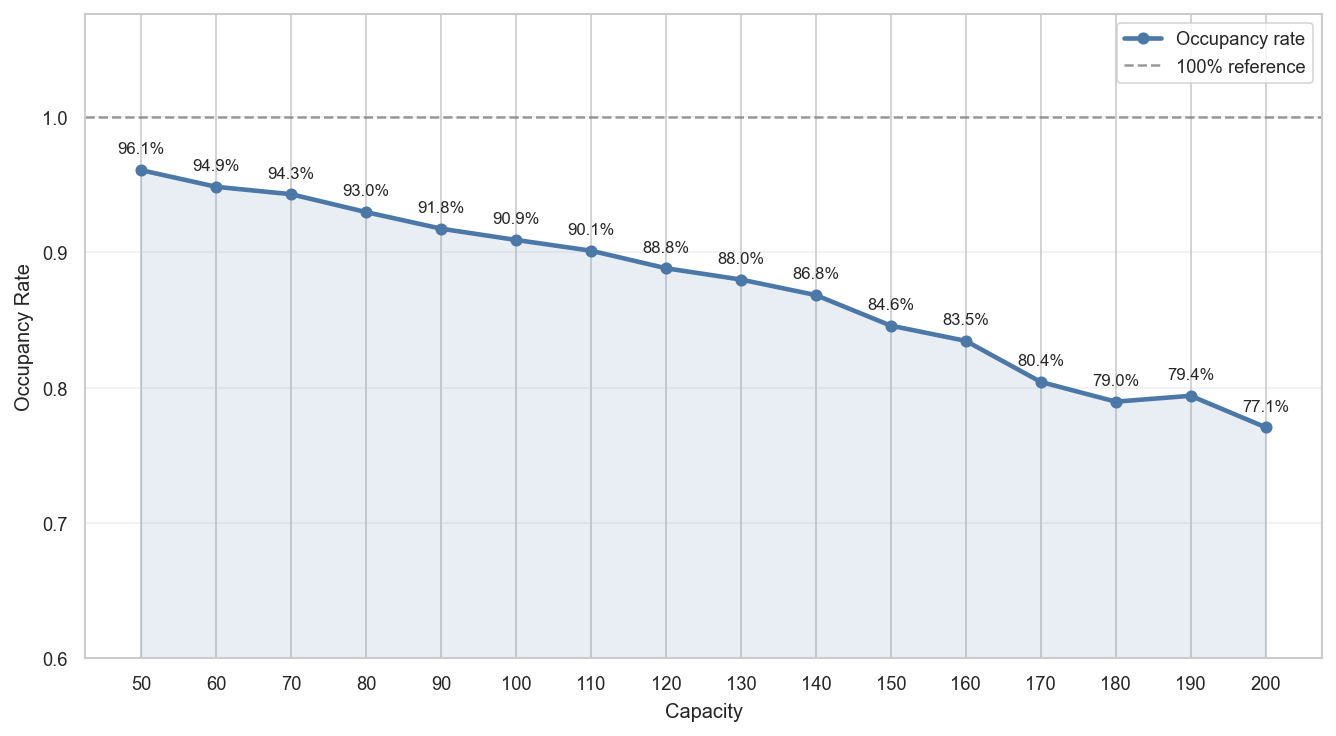

In [102]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="paper")

x = occ_strict_df["capacity"].values
y = occ_strict_df["occupancy_rate_strict365"].values

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
ax.plot(x, y, marker="o", linewidth=2.2, color="#4C78A8", label="Occupancy rate")
ax.fill_between(x, y, alpha=0.12, color="#4C78A8")
ax.axhline(1.0, linestyle="--", linewidth=1.2, color="gray", alpha=0.8, label="100% reference")

for xi, yi in zip(x, y):
    ax.text(xi, yi + 0.01, f"{yi*100:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Capacity")
ax.set_ylabel("Occupancy Rate")
#ax.set_title("Occupancy Rate vs Capacity")
ax.set_xticks(x)
ax.set_ylim(0.6, max(1.05, np.nanmax(y) * 1.12))
ax.legend(loc="best", frameon=True)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


fig.savefig(FIG_DIR / "occupancy_rate_vs_capacity.pdf", dpi=300, bbox_inches="tight")
